# 03. Statistical analysis

**Owner:** Anibal  \
**Inputs:** see `config/paths.yml`  \
**Outputs:** figures to `reports/figures/`, data to `data/processed/`

## Purpose

Question A: what is the relationship between demographic aging, rural depopulation and fire incidence in agricultural areas?


## Setup

Every chapter starts with this identical cell. Do not add ad-hoc paths below it — put new paths in `config/paths.yml`.

In [16]:
import importlib
import sys
from pathlib import Path
import warnings

# Make the src-layout package importable when the notebook kernel is not installed with -e .
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wildfires.config import CONVENTIONS, MIN_FIRE_HA, PATHS, STUDY_YEARS
from wildfires.viz import apply_theme, save_figure

apply_theme()
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

import statsmodels.api as sm
import wildfires.io as wildfires_io

wildfires_io = importlib.reload(wildfires_io)
load_icnf = wildfires_io.load_icnf
load_ine_population_age_all = wildfires_io.load_ine_population_age_all
load_ine_population_all = wildfires_io.load_ine_population_all
load_municipality_dimensions = wildfires_io.load_municipality_dimensions
load_panel = wildfires_io.load_panel
from wildfires.features import add_lags, cause_shares, log1p_safe

## Load panel

### INE (population dataset)

In [18]:
population_age_data = load_ine_population_age_all(
    years=range(STUDY_YEARS[0], STUDY_YEARS[1] + 1)
)

c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_01!$A:$O.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_06c!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 02'!$A:$S.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 04'!$A:$J.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workb

In [3]:
population_age_data

,municipality,dtcc,Total,0 a 14 anos,15 a 24 anos,ine_year,geo_level,25-64 anos,65 e mais anos__Total,75 e mais anos
0,Arcos de Valdevez,1601,20926,1994,1944,2019,municipality,10181,6807,4140
1,Caminha,1602,15877,1743,1546,2019,municipality,8478,4110,2120
2,Melgaço,1603,8093,646,661,2019,municipality,3845,2941,1867
3,Monção,1604,17869,1711,1535,2019,municipality,9348,5275,3009
4,Paredes de Coura,1605,8535,953,775,2019,municipality,4426,2381,1387
...,...,...,...,...,...,...,...,...,...,...
1843,Ribeira Brava,3107,13322,1550,1633,2024,municipality,7299,2840,1310
1844,Santa Cruz,3108,44816,6170,5233,2024,municipality,26252,7161,2899
1845,Santana,3109,6516,622,622,2024,municipality,3356,1916,988
1846,São Vicente,3110,5123,505,522,2024,municipality,2693,1403,670


### INCF (wildfire dataset)

In [20]:
wildfire_data = load_icnf(level="concelho")
wildfire_data

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Manue\\OneDrive - Hochschule Luzern\\Documentos\\HSLU\\8_4th_semester\\SustAnalytics\\sustainability-analytics\\data\\raw\\icnf\\EstatisticasIncendiosSGIF-2001-2025.xlsx'

### Municipality dimensions (data.gov)

In [17]:
municipality_dimensions = load_municipality_dimensions()
municipality_dimensions

,reference_date,area_km2,dtcc,municipality,district_code,district,nuts3_code,nuts3,nuts2_code,nuts2
0,2022-12-31,447.60,1601,Arcos de Valdevez,16,Viana do Castelo,111,Alto Minho,11,Norte
1,2022-12-31,136.52,1602,Caminha,16,Viana do Castelo,111,Alto Minho,11,Norte
2,2022-12-31,238.25,1603,Melgaço,16,Viana do Castelo,111,Alto Minho,11,Norte
3,2022-12-31,211.31,1604,Monção,16,Viana do Castelo,111,Alto Minho,11,Norte
4,2022-12-31,138.19,1605,Paredes de Coura,16,Viana do Castelo,111,Alto Minho,11,Norte
...,...,...,...,...,...,...,...,...,...,...
303,2022-12-31,42.68,3201,Porto Santo,32,Ilha de Porto Santo,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira
304,2022-12-31,65.46,3107,Ribeira Brava,31,Ilha da Madeira,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira
305,2022-12-31,81.31,3108,Santa Cruz,31,Ilha da Madeira,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira
306,2022-12-31,95.47,3109,Santana,31,Ilha da Madeira,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira


## Exploratory visualisations

### Fact checking the metrics - Study case: Penedono

In [8]:
pop_penedono = population_age_data.loc[
    population_age_data["municipality"] == "Penedono",
    ["0 a 14 anos", "15 a 24 anos", "25-64 anos", "65 e mais anos__Total", "75 e mais anos", "ine_year"]
]

In [9]:
pop_penedono

,0 a 14 anos,15 a 24 anos,25-64 anos,65 e mais anos__Total,75 e mais anos,ine_year
66,243,281,1359,708,423,2019
374,228,282,1355,707,403,2020
682,223,273,1286,941,526,2021
990,226,284,1319,957,533,2022
1298,223,275,1324,982,553,2023
1606,218,262,1332,996,553,2024


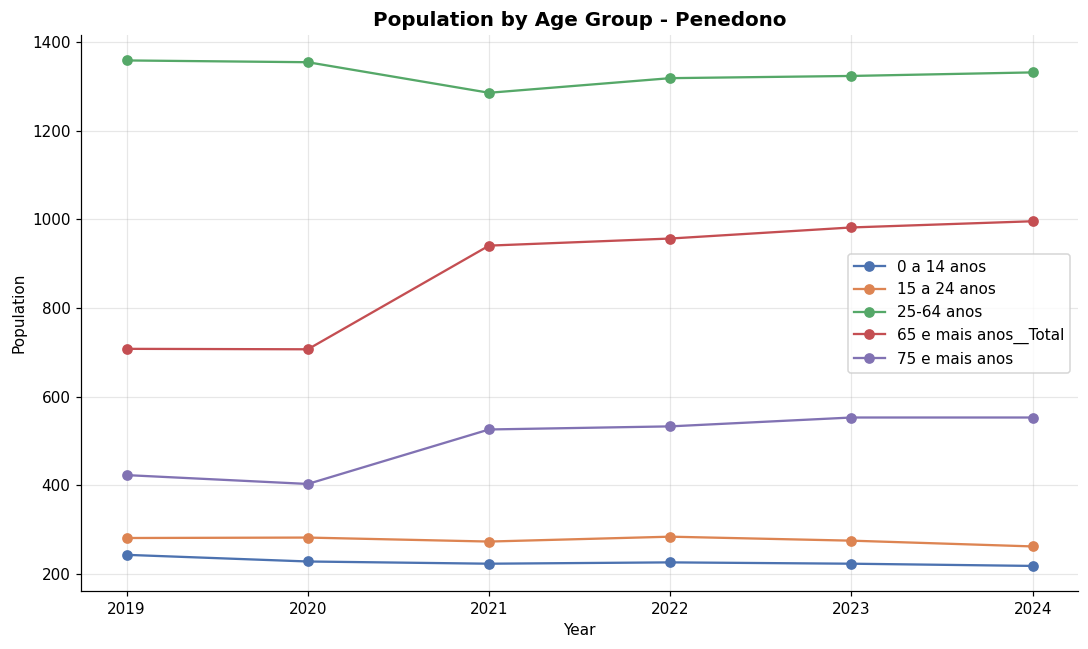

In [10]:
import matplotlib.pyplot as plt

# Set year as index (optional)
df = pop_penedono.set_index("ine_year")

plt.figure(figsize=(10, 6))

for col in ["0 a 14 anos", "15 a 24 anos", "25-64 anos", "65 e mais anos__Total", "75 e mais anos"]:
    plt.plot(df.index, df[col], marker="o", label=col)

plt.title("Population by Age Group - Penedono")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
wildfire_penedono = wildfire_data.loc[
    wildfire_data["year"].between(2001, 2025) &
    (wildfire_data["Concelho"] == "Penedono"),
    ["year", "Num_IncendiosRurais"]
]

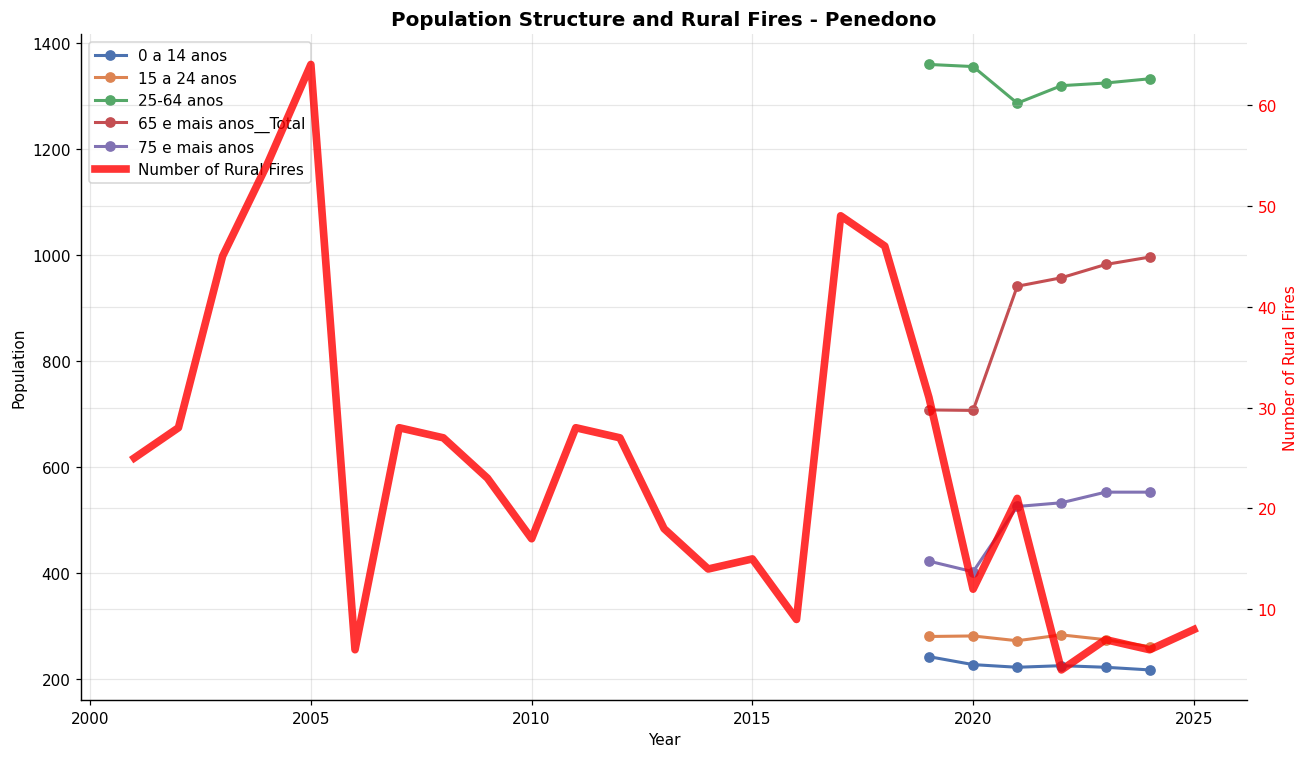

In [14]:
import matplotlib.pyplot as plt

# Population data
pop_df = pop_penedono.set_index("ine_year")

# Fire data
fire_df = wildfire_penedono.set_index("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

# Population lines (left axis)
population_cols = [
    "0 a 14 anos",
    "15 a 24 anos",
    "25-64 anos",
    "65 e mais anos__Total",  # adjust if your actual column name differs
    "75 e mais anos"
]

for col in population_cols:
    ax1.plot(
        pop_df.index,
        pop_df[col],
        marker="o",
        linewidth=2,
        label=col
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("Population")
ax1.grid(True, alpha=0.3)

# Fire axis (right)
ax2 = ax1.twinx()

ax2.plot(
    fire_df.index,
    fire_df["Num_IncendiosRurais"],
    color="red",
    linewidth=5,
    alpha=0.8,
    label="Number of Rural Fires"
)

ax2.set_ylabel("Number of Rural Fires", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Merge legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Population Structure and Rural Fires - Penedono")
plt.tight_layout()
plt.show()

**Conclusion:** Data shows a specific spike in 2021 both in ageing of the population and number of rural fires which may indicate the a link between the two variables or simply chance. However the number of fires was low in 2025, while in reality, the municipality of Penedono was devastated in 2025. Therefore, we conclude that the number of fires may not represent a good metric to represent the damage. Let's investigate other metrics.

### Burned area ratio - Penedono

In this chapter, we investigate the burned area ratio as a severity measure. This metric has been used in scientific research related to socio-economic impact (Chas-Amil et al., 2022 https://www.sciencedirect.com/science/article/pii/S0169204622002262), which is seems adequate to our research question.

In [29]:
# Build one municipality-year dataset for burned-area ratio and population ageing.
fire_area = wildfire_data[
    [
        "dtcc",
        "year",
        "AreaArdTotal_IncendioInicioConc",
        "AreaArdTotal_NoConcelho",
    ]
].copy()

# ICNF changed the populated total-area field after 2016.
fire_area["burned_area_ha"] = pd.to_numeric(
    fire_area["AreaArdTotal_IncendioInicioConc"], errors="coerce"
).fillna(pd.to_numeric(fire_area["AreaArdTotal_NoConcelho"], errors="coerce"))
fire_area = (
    fire_area.groupby(["dtcc", "year"], as_index=False, dropna=False)["burned_area_ha"]
    .sum(min_count=1)
)

municipality_area = municipality_dimensions[["dtcc", "municipality", "area_km2"]].copy()
municipality_area["municipality_area_ha"] = municipality_area["area_km2"] * 100

older_population = (
    population_age_data[
        ["dtcc", "ine_year", "65 e mais anos__Total", "75 e mais anos"]
    ]
    .rename(
        columns={
            "ine_year": "year",
            "65 e mais anos__Total": "population_over_65",
            "75 e mais anos": "population_over_75",
        }
    )
    .copy()
)

burned_area_ratio = (
    fire_area
    .merge(municipality_area, on="dtcc", how="left", validate="many_to_one")
    .merge(older_population, on=["dtcc", "year"], how="left", validate="one_to_one")
)
burned_area_ratio["burned_area_ratio"] = (
    burned_area_ratio["burned_area_ha"] / burned_area_ratio["municipality_area_ha"]
)
burned_area_ratio["burned_area_ratio_pct"] = burned_area_ratio["burned_area_ratio"] * 100

burned_area_ratio = burned_area_ratio[
    [
        "dtcc",
        "municipality",
        "year",
        "burned_area_ha",
        "area_km2",
        "municipality_area_ha",
        "burned_area_ratio",
        "burned_area_ratio_pct",
        "population_over_65",
        "population_over_75",
    ]
].sort_values(["municipality", "year"]).reset_index(drop=True)

burned_area_ratio

,dtcc,municipality,year,burned_area_ha,area_km2,municipality_area_ha,burned_area_ratio,burned_area_ratio_pct,population_over_65,population_over_75
0,1401,Abrantes,2001,225.144000,714.69,71469.0,0.003150,0.315023,NaN,NaN
1,1401,Abrantes,2002,105.748100,714.69,71469.0,0.001480,0.147964,NaN,NaN
2,1401,Abrantes,2003,16062.955000,714.69,71469.0,0.224754,22.475416,NaN,NaN
3,1401,Abrantes,2004,1158.198100,714.69,71469.0,0.016206,1.620560,NaN,NaN
4,1401,Abrantes,2005,7645.993600,714.69,71469.0,0.106983,10.698336,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6916,1012,Óbidos,2021,7.372500,141.55,14155.0,0.000521,0.052084,3213.0,1519.0
6917,1012,Óbidos,2022,2.755000,141.55,14155.0,0.000195,0.019463,3375.0,1617.0
6918,1012,Óbidos,2023,65.990531,141.55,14155.0,0.004662,0.466199,3480.0,1667.0
6919,1012,Óbidos,2024,2.459019,141.55,14155.0,0.000174,0.017372,3558.0,1728.0


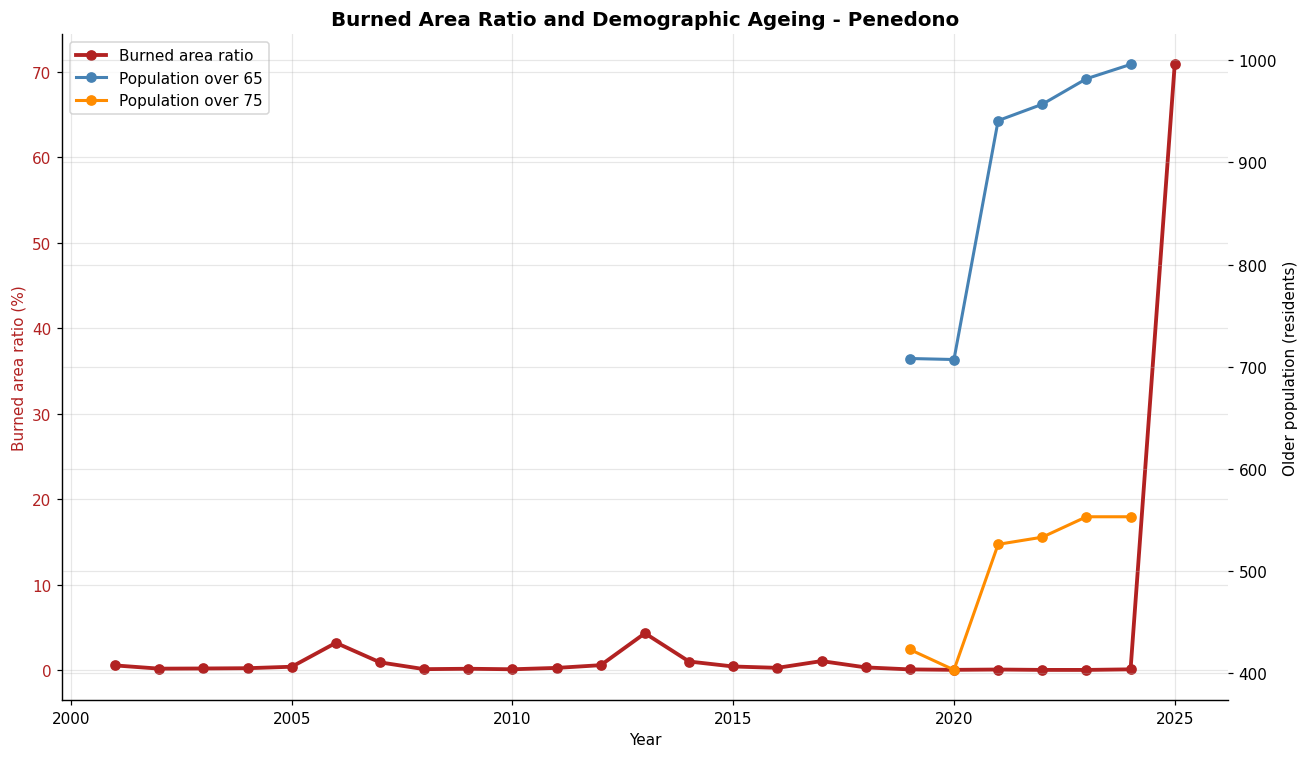

In [30]:
penedono_ratio = burned_area_ratio.loc[
    burned_area_ratio["municipality"].eq("Penedono"),
    ["year", "burned_area_ratio_pct", "population_over_65", "population_over_75"],
].sort_values("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    penedono_ratio["year"],
    penedono_ratio["burned_area_ratio_pct"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Burned area ratio",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Burned area ratio (%)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    penedono_ratio["year"],
    penedono_ratio["population_over_65"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Population over 65",
)
ax2.plot(
    penedono_ratio["year"],
    penedono_ratio["population_over_75"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Population over 75",
)
ax2.set_ylabel("Older population (residents)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Burned Area Ratio and Demographic Ageing - Penedono")
fig.tight_layout()
plt.show()

**Conclusion:** The percentage of burned area seems to represent a better metric for the damage caused by the fire (spike in 2025 correspond to the catastrophic fires over the last year). However, we cannot conclude if the demographic ageing after 2020 have contributed to these fires in 2025. Therefore, we should verify if there is a pattern over the country.

### Burned area ratio - Country level

In [31]:
# Build the country-level burned-area ratio and ageing dataset.
portugal_area = municipality_dimensions["area_km2"].sum()
portugal_area_ha = portugal_area * 100

country_burned_area = (
    fire_area.groupby("year", as_index=False)["burned_area_ha"]
    .sum(min_count=1)
)
country_burned_area["portugal_area_km2"] = portugal_area
country_burned_area["portugal_area_ha"] = portugal_area_ha
country_burned_area["burned_area_ratio"] = (
    country_burned_area["burned_area_ha"] / country_burned_area["portugal_area_ha"]
)
country_burned_area["burned_area_ratio_pct"] = (
    country_burned_area["burned_area_ratio"] * 100
)

country_older_population = (
    population_age_data.groupby("ine_year", as_index=False)["65 e mais anos__Total"]
    .sum(min_count=1)
    .rename(
        columns={
            "ine_year": "year",
            "65 e mais anos__Total": "population_over_65",
        }
    )
)

portugal_burned_area_ratio = (
    country_burned_area
    .merge(country_older_population, on="year", how="left", validate="one_to_one")
    [[
        "year",
        "burned_area_ha",
        "portugal_area_km2",
        "portugal_area_ha",
        "burned_area_ratio",
        "burned_area_ratio_pct",
        "population_over_65",
    ]]
    .sort_values("year")
    .reset_index(drop=True)
)

portugal_burned_area_ratio

,year,burned_area_ha,portugal_area_km2,portugal_area_ha,burned_area_ratio,burned_area_ratio_pct,population_over_65
0,2001,117420.438657,92225.18,9222518.0,0.012732,1.273193,NaN
1,2002,130849.078350,92225.18,9222518.0,0.014188,1.418800,NaN
2,2003,471750.049431,92225.18,9222518.0,0.051152,5.115198,NaN
3,2004,151369.876610,92225.18,9222518.0,0.016413,1.641307,NaN
4,2005,346717.819232,92225.18,9222518.0,0.037595,3.759470,NaN
5,2006,83705.863650,92225.18,9222518.0,0.009076,0.907625,NaN
6,2007,36412.547360,92225.18,9222518.0,0.003948,0.394822,NaN
7,2008,19897.219299,92225.18,9222518.0,0.002157,0.215746,NaN
8,2009,92125.662431,92225.18,9222518.0,0.009989,0.998921,NaN
9,2010,140953.185960,92225.18,9222518.0,0.015284,1.528359,NaN


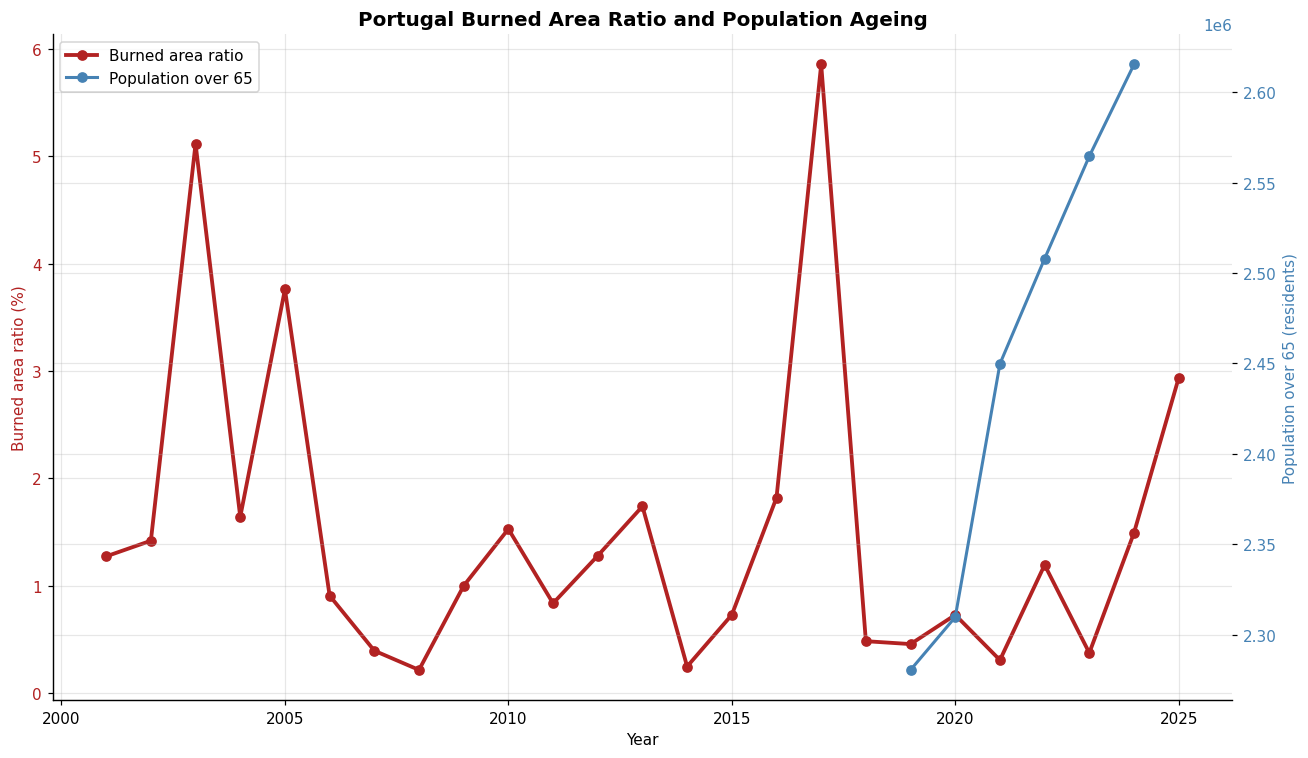

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    portugal_burned_area_ratio["year"],
    portugal_burned_area_ratio["burned_area_ratio_pct"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Burned area ratio",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Burned area ratio (%)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    portugal_burned_area_ratio["year"],
    portugal_burned_area_ratio["population_over_65"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Population over 65",
)
ax2.set_ylabel("Population over 65 (residents)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Portugal Burned Area Ratio and Population Ageing")
fig.tight_layout()
plt.show()

**Conclusion:** Over the country we can observe ciclic patterns of fire incidence. The population over 65 is drastically increasing in last years. However, we do not have data about population demographics before 2019, which makes it hard to draw relationship conclusions.

## Descriptive relationships

In [ ]:
# TODO


## Correlation structure and spurious-correlation checks

In [ ]:
# TODO


## Model specification

In [ ]:
# TODO


## Panel regression

In [ ]:
# TODO


## Lag structure and Granger causality

In [ ]:
# TODO


## Robustness checks

In [ ]:
# TODO


## Interpretation and limitations

In [ ]:
# TODO


## Takeaways

Three to five bullets. These get lifted verbatim into `05_discussion.ipynb`, so
write them as claims, not as descriptions of what you did.

-
-
-
